In [124]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np
pd.set_option('display.max_columns', None)
import analysis as  an  
sns.set()





from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report, confusion_matrix

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn import set_config




## Data cleaning and processing 

In [3]:
cols = {
    'Cell':'cell_phone',
    
    'main':'electricity',
    'exp':'expenditure',
    'roofc':'roof_condition'


}

response_dict_1 = {
    1:'Yes',
    2:"No",
    9:'Unspecified'
}
yes_no_dict = {
    1: "Yes",
    2: "No",
    9: "Unspecified"
}
male = {1: 'Male', 2: 'Female'}

ethnicity_dict = {
    1: "African/Black",
    2: "Coloured",
    3: "Indian/Asian",
    4: "White"
}
geo_type_data = {
    1: "Urban formal",
    2: "Urban informal",
    3: "Tribal areas",
    4: "Rural formal",
    5: "Other"
}
province = {
    1: "Western Cape",
    2: "Eastern Cape",
    3: "Northern Cape",
    4: "Free State",
    5: "KwaZulu-Natal",
    6: "North West",
    7: "Gauteng",
    8: "Mpumalanga",
    9: "Limpopo"
}


material_dict = {
    1: "Bricks",
    2: "Cement block/concrete",
    3: "Corrugated iron/zinc",
    4: "Wood",
    5: "Plastic",
    6: "Cardboard",
    7: "Mud and cement mix",
    8: "Wattle and daub",
    9: "Tile",
    10: "Mud",
    11: "Thatching/grass",
    12: "Asbestos",
    13: "Other",
    99: "Unspecified"
}
income_dict = {
    1: 'R0',
    2: 'R1-R199',
    3: 'R200-R399',
    4: 'R400-R799',
    5: 'R800-R1 199',
    6: 'R1 200-R1 799',
    7: 'R1 800-R2 499',
    8: 'R2 500-R4 999',
    9: 'R5 000-R9 999',
    10: 'R10 000 or more',
    11: 'Do not know',
    12: 'Refuse',
    99: 'Unspecified'
}

In [4]:
my_columns = list(cols.values())
other = ['uqnr', 'head_age', 'house_wgt', 'prov', 'geotype', 'head_popgrp', 'head_sex','year']
column_list = my_columns + other
column_list
 

['cell_phone',
 'electricity',
 'expenditure',
 'roof_condition',
 'uqnr',
 'head_age',
 'house_wgt',
 'prov',
 'geotype',
 'head_popgrp',
 'head_sex',
 'year']

#### pulling ddata 

In [4]:
clean_df = pd.DataFrame()
clean_df_list = []
for i in range(2002,2018):
    print(i)
    df =  pd.read_csv(f"data_room/{i}.csv", encoding='latin1')
    # making then lowe case 
    for name in df.columns:
        lower = name.lower()
        df = df.rename(columns={name:lower})
        
        for match_column,new_column in cols.items():
            for col  in df.columns:
                if  col.endswith(match_column):

                        df = df.rename(columns={col:new_column})
                if 'mains' in col:
                     df = df.rename(columns={col:'electricity'})
                if 'expe' in col:
                     df = df.rename(columns={col:'expenditure'})
                if 'tota' in col:
                     df = df.rename(columns={col:'expenditure'})
                if 'cell' in col:
                     df = df.rename(columns={col:'cell_phone'})
                     
         
    provin = df['prov'].unique()
    province = provin[0]
    df['year'] = i
    df = df.loc[:, ~df.columns.duplicated()]



  
    df = df[column_list]

   
    
    clean_df_list.append(df)
clean_df = pd.concat(clean_df_list)



2002


/var/folders/hv/m7d19hld69qb83g8n_7x10tc0000gn/T/ipykernel_2223/2081690035.py:5: DtypeWarning: Columns (112) have mixed types. Specify dtype option on import or set low_memory=False.
  df =  pd.read_csv(f"data_room/{i}.csv", encoding='latin1')


2003


/var/folders/hv/m7d19hld69qb83g8n_7x10tc0000gn/T/ipykernel_2223/2081690035.py:5: DtypeWarning: Columns (40,151) have mixed types. Specify dtype option on import or set low_memory=False.
  df =  pd.read_csv(f"data_room/{i}.csv", encoding='latin1')


2004
2005
2006
2007


...

2012


/var/folders/hv/m7d19hld69qb83g8n_7x10tc0000gn/T/ipykernel_2223/2081690035.py:5: DtypeWarning: Columns (146,149,152,251,257,258,259,260) have mixed types. Specify dtype option on import or set low_memory=False.
  df =  pd.read_csv(f"data_room/{i}.csv", encoding='latin1')


2013


/var/folders/hv/m7d19hld69qb83g8n_7x10tc0000gn/T/ipykernel_2223/2081690035.py:5: DtypeWarning: Columns (129,132,135,247,252,253,254,255) have mixed types. Specify dtype option on import or set low_memory=False.
  df =  pd.read_csv(f"data_room/{i}.csv", encoding='latin1')


2014
2015
2016
2017


In [6]:
clean_df['cell_phone'] =  clean_df['cell_phone'].replace({ 1: "Yes",
    2: "No",
    9: "Unspecified"})
clean_df['roof_condition'] =  clean_df['roof_condition'].replace({   1: "Bricks",
    2: "Cement block/concrete",
    3: "Corrugated iron/zinc",
    4: "Wood",
    5: "Plastic",
    6: "Cardboard",
    7: "Mud and cement mix",
    8: "Wattle and daub",
    9: "Tile",
    10: "Mud",
    11: "Thatching/grass",
    12: "Asbestos",
    13: "Other",
    99: "Unspecified"})
clean_df['head_sex'] =  clean_df['head_sex'].replace({1: 'Male', 2: 'Female'})

clean_df['prov'] =  clean_df['prov'].replace({
    1: "Western Cape",
    2: "Eastern Cape",
    3: "Northern Cape",
    4: "Free State",
    5: "KwaZulu-Natal",
    6: "North West",
    7: "Gauteng",
    8: "Mpumalanga",
    9: "Limpopo"
})
clean_df['electricity'] =  clean_df['electricity'].replace({  1: "Yes",
    2: "No",
    9: "Unspecified"})
clean_df['geotype'] =  clean_df['geotype'].replace({   1: "Urban formal",
    2: "Urban informal",
    3: "Tribal areas",
    4: "Rural formal",
    5: "Other"})
clean_df['head_popgrp'] =  clean_df['head_popgrp'].replace({  1: "African/Black",
    2: "Coloured",
    3: "Indian/Asian",
    4: "White"})

clean_df['expenditure'] =  clean_df['expenditure'].replace({ 1: 'R0',
    2: 'R1-R199',
    3: 'R200-R399',
    4: 'R400-R799',
    5: 'R800-R1 199',
    6: 'R1 200-R1 799',
    7: 'R1 800-R2 499',
    8: 'R2 500-R4 999',
    9: 'R5 000-R9 999',
    10: 'R10 000 or more',
    11: 'Do not know',
    12: 'Refuse',
    99: 'Unspecified'})




clean_df

,cell_phone,electricity,expenditure,roof_condition,uqnr,head_age,house_wgt,prov,geotype,head_popgrp,head_sex,year
0,No,Yes,R 2 500 - R 4 999,Good,1011001002201,46,472.456808,Western Cape,Urban formal,White,Female,2002
1,Yes,Yes,R 2 500 - R 4 999,Needs minor repairs,1011001004901,38,380.486853,Western Cape,Urban formal,White,Male,2002
2,No,Yes,R 400 - R 799,Good,1011001007501,38,471.388601,Western Cape,Urban formal,Coloured,Female,2002
3,No,Yes,R 400 - R 799,Good,1011001007502,36,471.388601,Western Cape,Urban formal,Coloured,Female,2002
4,Yes,Yes,R 400 - R 799,Good,1011001010101,56,377.697623,Western Cape,Urban formal,White,Female,2002
...,...,...,...,...,...,...,...,...,...,...,...,...
21220,Yes,Yes,R10 000 or more,Corrugated iron/zinc,987106510000011601,70,451.601290,Limpopo,Urban informal,African/Black,Male,2017
21221,Yes,Yes,R800-R1 199,Wood,987106510000013101,22,785.328611,Limpopo,Urban informal,African/Black,Male,2017
21222,Yes,Yes,R200-R399,Corrugated iron/zinc,987106510000014601,29,785.328611,Limpopo,Urban informal,African/Black,Male,2017
21223,Yes,Yes,R5 000-R9 999,Wood,987106510000016101,43,703.739834,Limpopo,Urban informal,African/Black,Female,2017


In [135]:
df = pd.read_csv("clean_data.csv")


/Users/phulusoravhuhali/Desktop/assigment_capsnap/venv/lib/python3.9/site-packages/seaborn/distributions.py:413: UserWarning: `bins` cannot be 'auto' when using weights. Setting `bins=10`, but you will likely want to adjust.
  warnings.warn(msg, UserWarning)


The age that owns the most houses (weighted by house_wgt) is 32.0


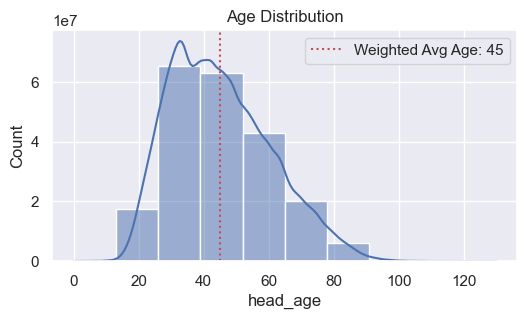

In [6]:

an.plot_age_distribution(df,'head_age','house_wgt')

In [48]:
df_phones = df[df['cell_phone'] == 'Yes']

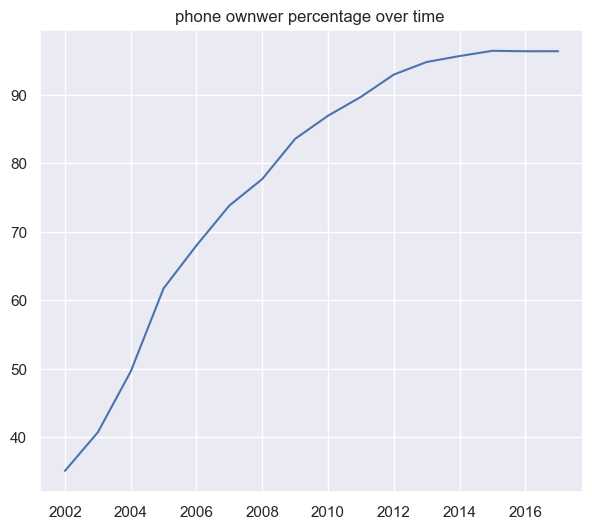

In [10]:
df_yy = an.phone_calculate_weighted_percentage(
    df, 
    year_range=range(2002, 2018), 
    column='cell_phone', 
    weights_col='house_wgt'  
)

df_yy =  df_yy[df_yy['cell_phone'] == 'Yes']
fig ,ax =  plt.subplots(figsize = (7,6))
ax.plot(df_yy['year'],df_yy['percentage'])
ax.set_title('phone ownwer percentage over time ');


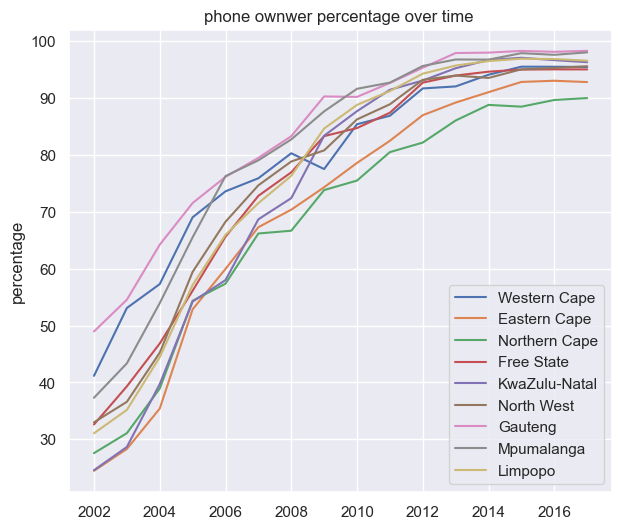

In [14]:
provinces = df['prov'].unique()
fig ,ax =  plt.subplots(figsize = (7,6))
for province in provinces:
    df_pp = df[df['prov'] == province]
    df_plt = an.phone_calculate_weighted_percentage(
    df_pp, 
    year_range=range(2002, 2018), 
    column='cell_phone', 
    weights_col='house_wgt')
    df_plt =  df_plt[df_plt['cell_phone'] == 'Yes']
    ax.plot(df_plt['year'],df_plt['percentage'],label = province)
ax.set_title('phone ownwer percentage over time ');
ax.set_ylabel("percentage")
ax.legend();

    



In [11]:

for i in range(2002, 2018): 
    
    df_y = df[df['year'] == i]    
    print(an.percentage_phone(df_y,'cell_phone',i))

1    32.885804
Name: percentage, dtype: float64  %  in 2002  has cell phones
1    38.587843
Name: percentage, dtype: float64  %  in 2003  has cell phones
1    46.9874
Name: percentage, dtype: float64  %  in 2004  has cell phones
0    55.985339
Name: percentage, dtype: float64  %  in 2005  has cell phones
0    61.766492
Name: percentage, dtype: float64  %  in 2006  has cell phones
0    68.70981
Name: percentage, dtype: float64  %  in 2007  has cell phones
0    76.036658
Name: percentage, dtype: float64  %  in 2008  has cell phones
0    82.369679
Name: percentage, dtype: float64  %  in 2009  has cell phones
0    85.606803
Name: percentage, dtype: float64  %  in 2010  has cell phones
0    88.595232
Name: percentage, dtype: float64  %  in 2011  has cell phones
0    92.048954
Name: percentage, dtype: float64  %  in 2012  has cell phones
0    93.872644
Name: percentage, dtype: float64  %  in 2013  has cell phones
0    94.791626
Name: percentage, dtype: float64  %  in 2014  has cell phones
0 

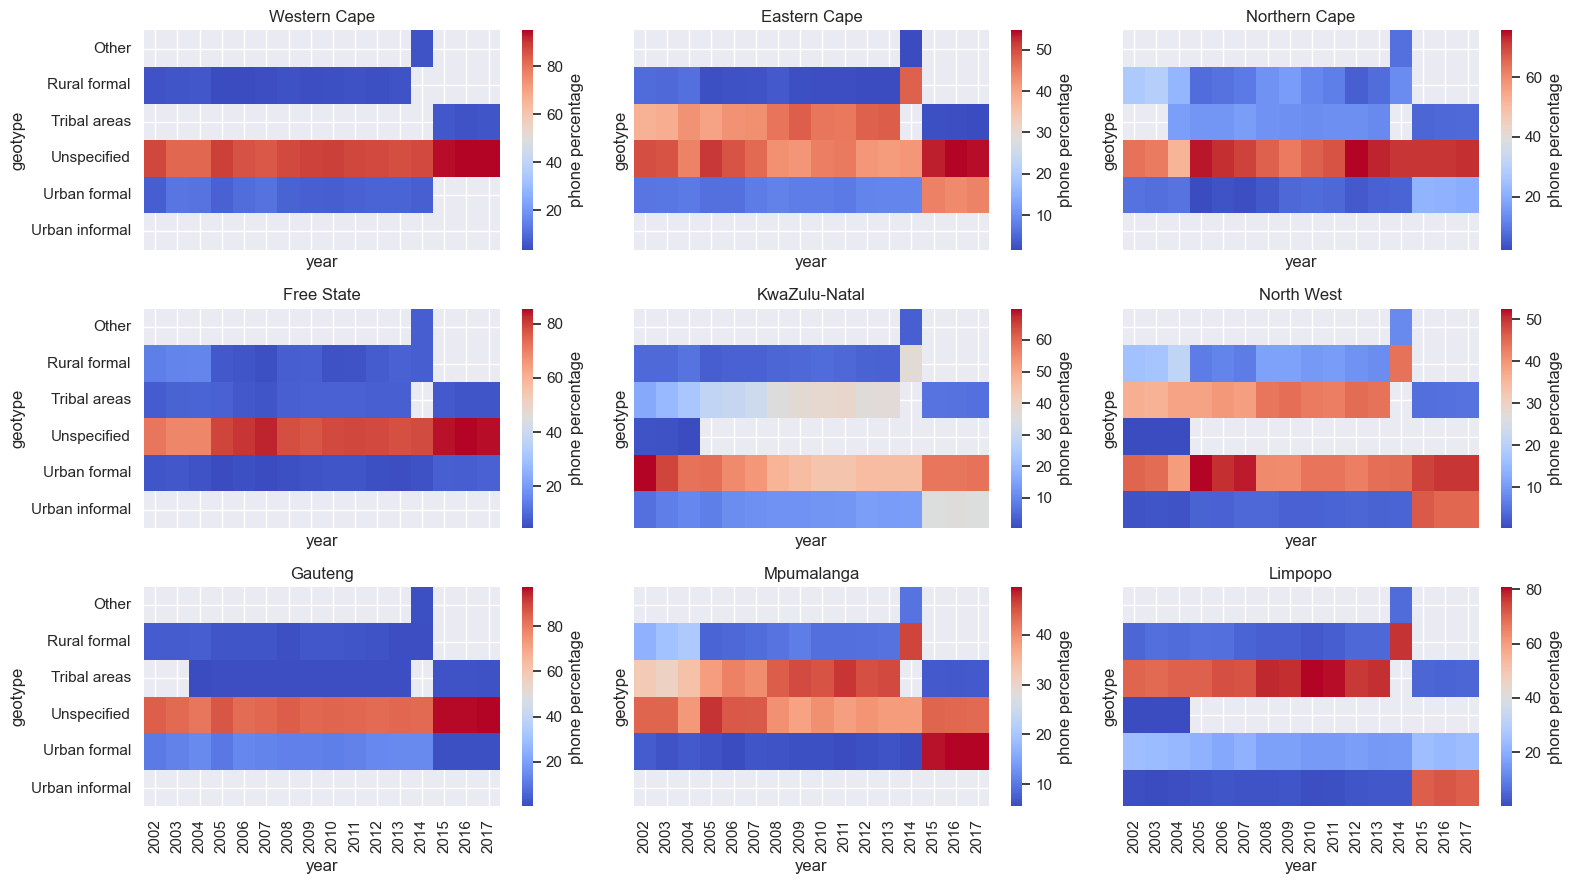

In [75]:
fig, ax = plt.subplots(3, 3, figsize=(16, 9), sharex=True, sharey=True)
axes = ax.flatten()

for prov, axis in zip(df['prov'].unique(), axes):
    df_prov = df_phones[df_phones['prov'] == prov]
    df_list = []

    for year in range(2002, 2018):
        df_year = df_prov[df_prov['year'] == year]
        
        weighted_counts = (
            df_year.groupby(['geotype', 'cell_phone'])['house_wgt'].sum().reset_index(name='weighted_count')
        )
        total_weighted = weighted_counts['weighted_count'].sum()
        weighted_counts['percentage'] = (weighted_counts['weighted_count'] / total_weighted) * 100
        
        weighted_counts['year'] = year
        df_list.append(weighted_counts)
    
    result_df = pd.concat(df_list, ignore_index=True)
    dff = result_df.pivot(index='geotype', columns='year', values='percentage')
    
    sns.heatmap(
        dff,
        cbar_kws={"label": "phone percentage"},
        cmap='coolwarm',
        ax=axis
    )
    axis.set_title(f"{prov}")

plt.tight_layout()
plt.show()


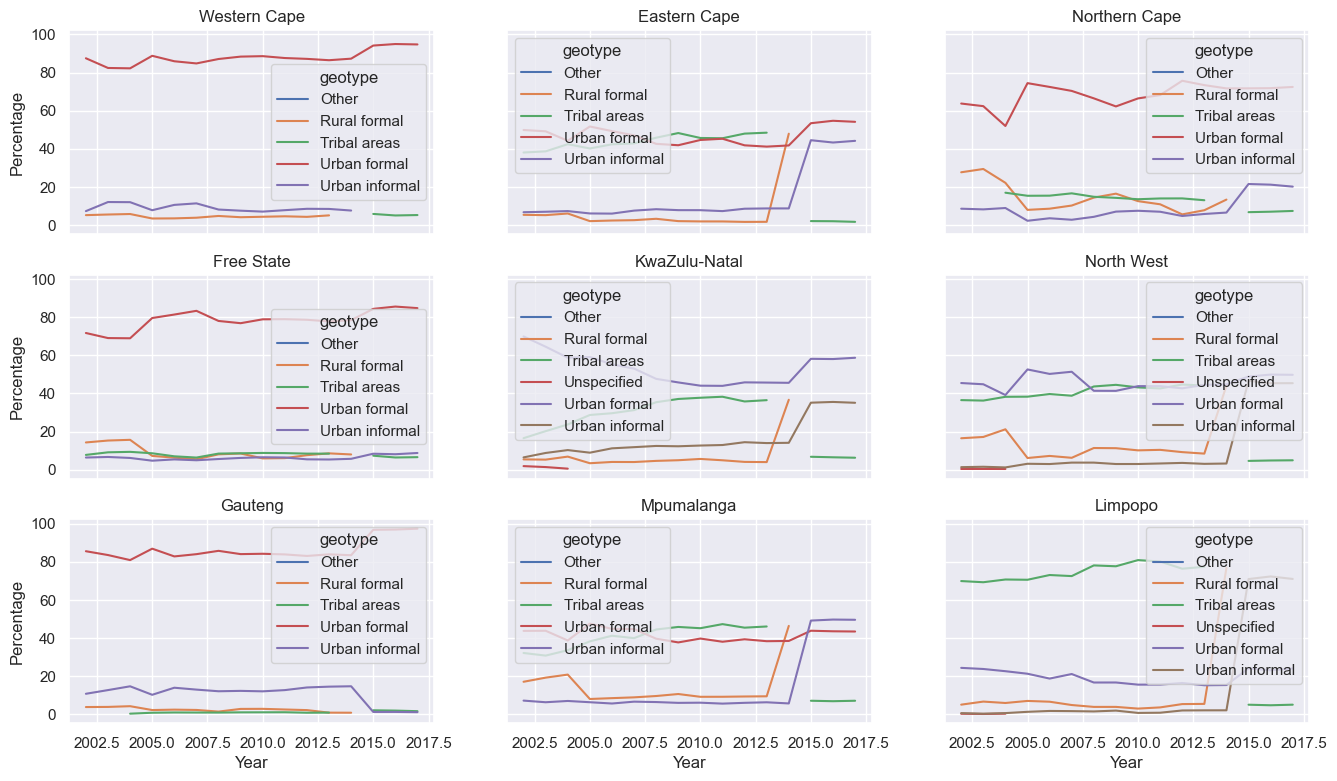

In [106]:
geotypes = df['geotype'].unique()

fig, ax = plt.subplots(3, 3, figsize=(16, 9), sharex=True, sharey=True)
axes = ax.flatten()

for prov, axis in zip(df['prov'].unique(), axes):
    df_prov = df_phones[df_phones['prov'] == prov]
    df_list = []

    for year in range(2002, 2018):
        df_year = df_prov[df_prov['year'] == year]
        
        weighted_counts = (
            df_year.groupby(['geotype', 'cell_phone'])['house_wgt'].sum().reset_index(name='weighted_count')
        )
        total_weighted = weighted_counts['weighted_count'].sum()
        weighted_counts['percentage'] = (weighted_counts['weighted_count'] / total_weighted) * 100
        
        weighted_counts['year'] = year
        df_list.append(weighted_counts)
    
    result_df = pd.concat(df_list, ignore_index=True)
    dff = result_df.pivot(index='year', columns='geotype', values='percentage')
    
    dff.plot(ax=axis)
    axis.set_title(f"{prov}")
    axis.set_ylabel('Percentage')
    axis.set_xlabel('Year')




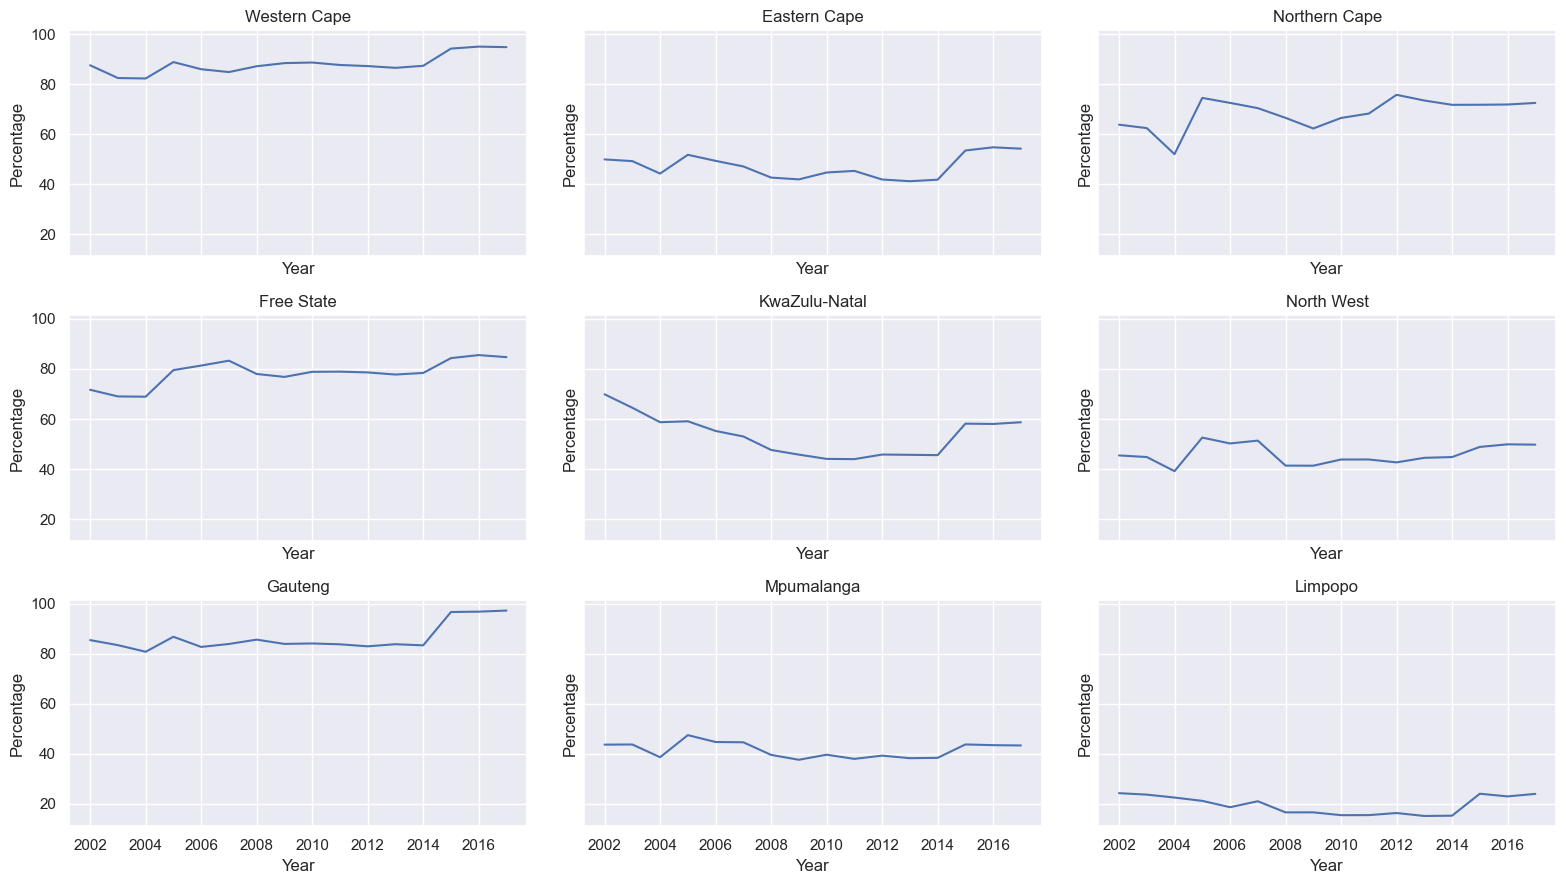

In [109]:
geotypes = df['geotype'].unique()

fig, ax = plt.subplots(3, 3, figsize=(16, 9), sharex=True, sharey=True)
axes = ax.flatten()

for prov, axis in zip(df['prov'].unique(), axes):
    df_prov = df_phones[df_phones['prov'] == prov]
    df_list = []

    for year in range(2002, 2018):
        df_year = df_prov[df_prov['year'] == year]
        
        weighted_counts = (
            df_year.groupby(['geotype', 'cell_phone'])['house_wgt'].sum().reset_index(name='weighted_count')
        )
        total_weighted = weighted_counts['weighted_count'].sum()
        weighted_counts['percentage'] = (weighted_counts['weighted_count'] / total_weighted) * 100
        
        weighted_counts['year'] = year
        df_list.append(weighted_counts)
    
    result_df = pd.concat(df_list, ignore_index=True)
    result_df = result_df[result_df['geotype'] == 'Urban formal']

    axis.plot(result_df['year'], result_df['percentage'], label=prov)
    axis.set_title(f"{prov}")
    axis.set_ylabel('Percentage')
    axis.set_xlabel('Year')

plt.tight_layout()
plt.show()


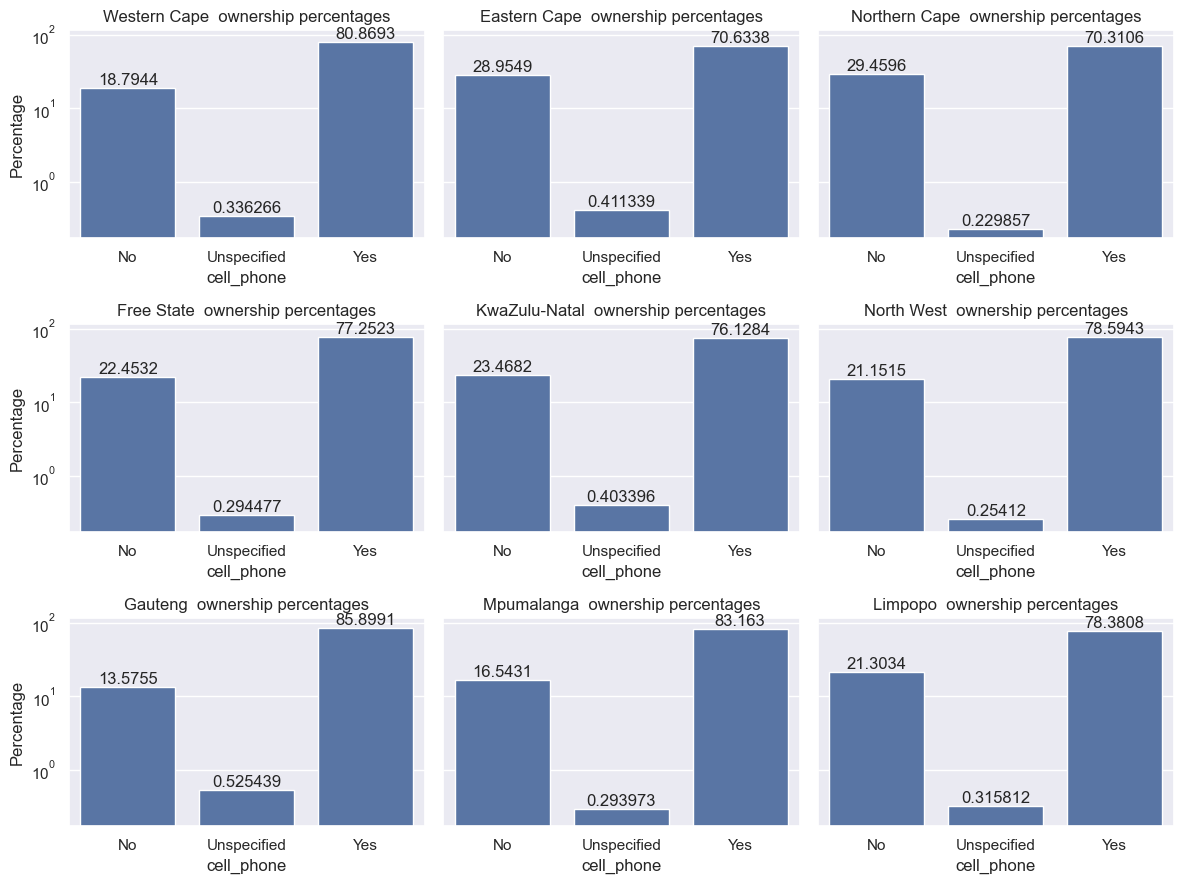

In [24]:
an.plot_phone_ownership(df,'cell_phone','prov','house_wgt','')

# Age 

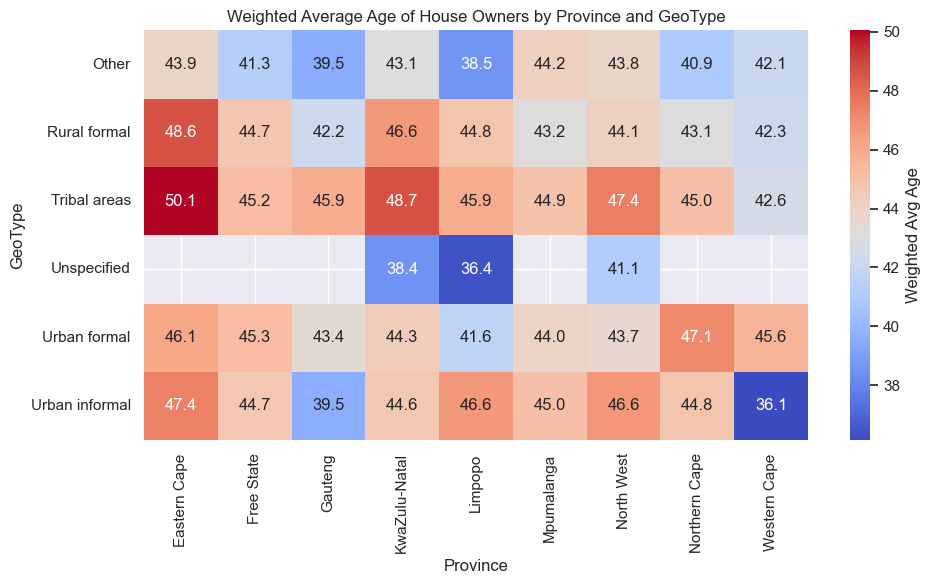

In [4]:


an.plot_weighted_avg_age_heatmap(df_phones,'geotype','head_age','house_wgt','prov')

/var/folders/hv/m7d19hld69qb83g8n_7x10tc0000gn/T/ipykernel_4635/955850173.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_y.groupby(['prov','geotype'])
/var/folders/hv/m7d19hld69qb83g8n_7x10tc0000gn/T/ipykernel_4635/955850173.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_y.groupby(['prov','geotype'])
/var/folders/hv/m7d19hld69qb83g8n_7x10tc0000gn/T/ipykernel_4635/955850173.py:8: DeprecationW

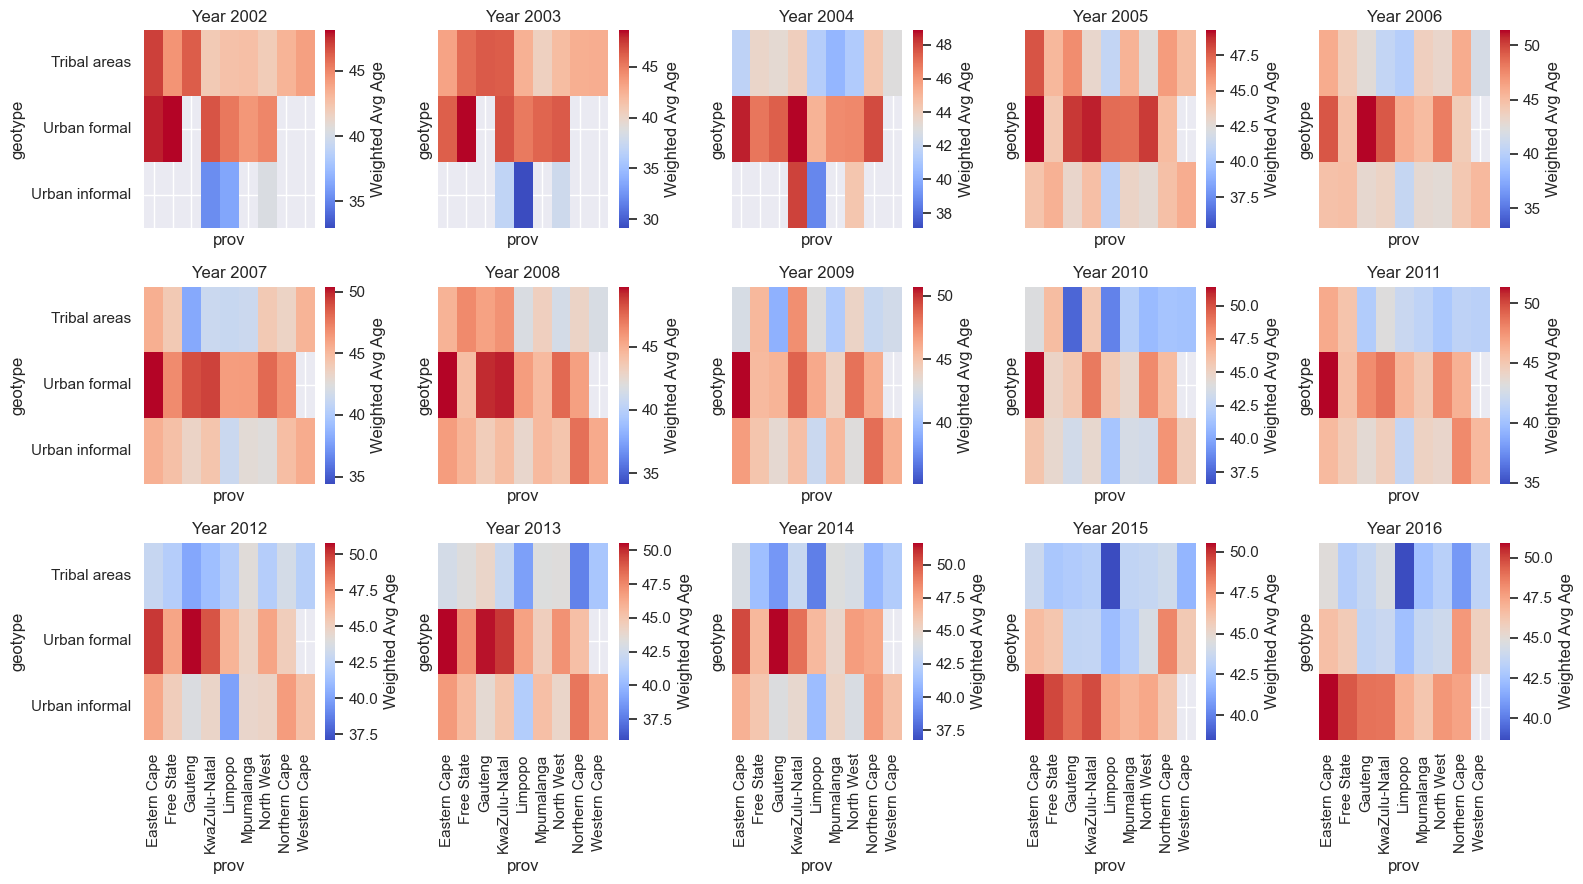

In [22]:
fig, ax = plt.subplots(3, 5, figsize=(16, 9), sharex=True, sharey=True)  
axes = ax.flatten()  

for i, axis in zip(range(2002, 2018), axes):  
    df_y = df_phones[df_phones['year'] == i]
    
    grouped = (
        df_y.groupby(['prov','geotype'])
        .apply(
            lambda x: (x['head_age'] * x['house_wgt']).sum() / x['house_wgt'].sum()
        )
        .reset_index(name="weighted_avg_age")
    )

    heatmap_data = grouped.pivot(
        index='geotype', columns='prov', values="weighted_avg_age"
    )

    sns.heatmap(
        heatmap_data,
        cmap="coolwarm",
        cbar_kws={"label": "Weighted Avg Age"},
        ax=axis
    )
    axis.set_title(f"Year {i}") 


fig.tight_layout() 
plt.show()


/var/folders/hv/m7d19hld69qb83g8n_7x10tc0000gn/T/ipykernel_4635/443493952.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_year.groupby(['geotype'])
/var/folders/hv/m7d19hld69qb83g8n_7x10tc0000gn/T/ipykernel_4635/443493952.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_year.groupby(['geotype'])
/var/folders/hv/m7d19hld69qb83g8n_7x10tc0000gn/T/ipykernel_4635/443493952.py:14: DeprecationWarnin

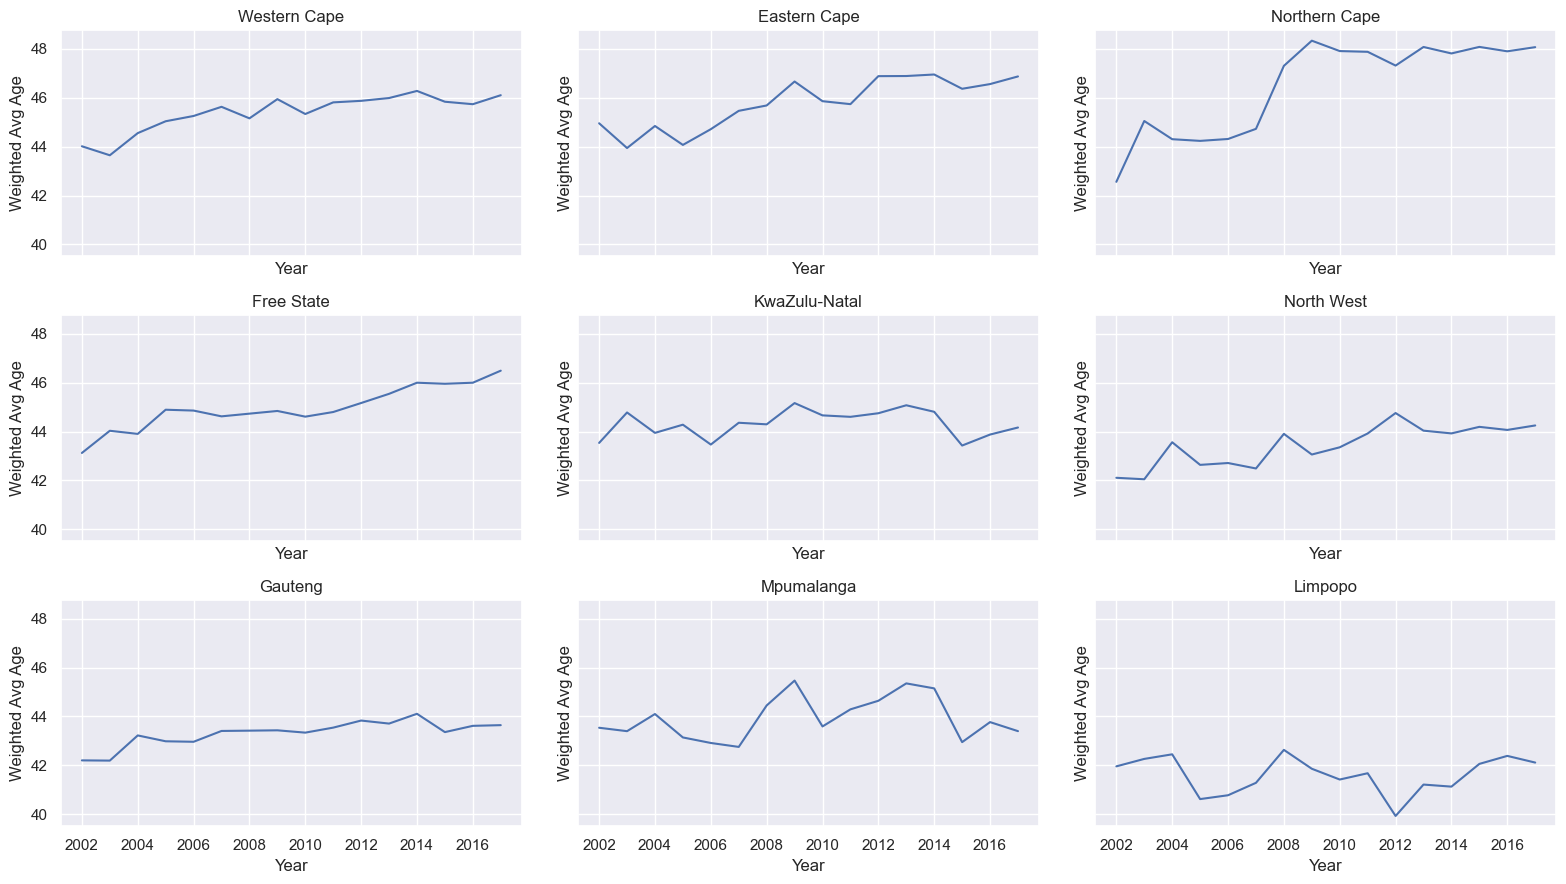

In [97]:
geotypes = df['geotype'].unique()

fig, ax = plt.subplots(3, 3, figsize=(16, 9), sharex=True, sharey=True)
axes = ax.flatten()

for prov, axis in zip(df['prov'].unique(), axes):
    df_prov = df_phones[df_phones['prov'] == prov]
    df_list = []

    for year in range(2002, 2018):
        df_year = df_prov[df_prov['year'] == year]
        
        weighted_avg_age = (
            df_year.groupby(['geotype'])
            .apply(
                lambda x: (x['head_age'] * x['house_wgt']).sum() / x['house_wgt'].sum()
            )
            .reset_index(name="weighted_avg_age")
        )
        
        weighted_avg_age['year'] = year
        df_list.append(weighted_avg_age)
    
    result_df = pd.concat(df_list, ignore_index=True)
    result_df = result_df[result_df['geotype'] == 'Urban formal']

    axis.plot(result_df['year'], result_df['weighted_avg_age'], label=prov)
    axis.set_title(f"{prov}")
    axis.set_ylabel('Weighted Avg Age')
    axis.set_xlabel('Year')

plt.tight_layout()
plt.show()

In [125]:
categorical_cols = [x for x in df.columns if type(df[x][1]).__name__ == 'str']


numerical_cols = [x for x in df.columns if type(df[x][1]).__name__ != 'str']




In [126]:
categorical_transformer = Pipeline(steps=[

    ("imputer", SimpleImputer(strategy="most_frequent")),

    ("onehot", OneHotEncoder(handle_unknown="ignore"))

])



numerical_transformer = Pipeline(steps=[

    ("imputer", SimpleImputer(strategy="mean")),

    ("scaler", StandardScaler())

])


In [127]:

preprocessor = ColumnTransformer(transformers=[
("num", numerical_transformer, numerical_cols),

    ("cat", categorical_transformer, categorical_cols)

])



In [137]:
df.columns

Index(['Unnamed: 0', 'cell_phone', 'electricity', 'expenditure',
       'roof_condition', 'uqnr', 'head_age', 'house_wgt', 'prov', 'geotype',
       'head_popgrp', 'head_sex', 'year'],
      dtype='object')

In [150]:
# Define the independent variables (features) and dependent variable (target)
X = df.drop(columns=["Unnamed: 0", "uqnr", "cell_phone"])
y = df["cell_phone"].apply(lambda x: 1 if x == "Yes" else 0)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define the preprocessor for numerical and categorical features
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# Logistic Regression
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42))
])

# Decision Tree
decision_tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# Random Forest
random_forest_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

pipelines = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline
}

results = {}

for name, pipeline in pipelines.items():
    # Train the model
    pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = pipeline.predict(X_test)
    
    # Evaluation
    results[name] = classification_report(y_test, y_pred, output_dict=True)

results

/Users/phulusoravhuhali/Desktop/assigment_capsnap/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


KeyboardInterrupt: 

In [151]:
results

{'Logistic Regression': {'0': {'precision': 0.7025421715371822,
   'recall': 0.5668551710917281,
   'f1-score': 0.6274468197973583,
   'support': 20866.0},
  '1': {'precision': 0.8590894917368257,
   'recall': 0.9166860755281983,
   'f1-score': 0.886953722334004,
   'support': 60110.0},
  'accuracy': 0.8265411973918197,
  'macro avg': {'precision': 0.780815831637004,
   'recall': 0.7417706233099632,
   'f1-score': 0.7572002710656811,
   'support': 80976.0},
  'weighted avg': {'precision': 0.8187501765905385,
   'recall': 0.8265411973918197,
   'f1-score': 0.8200836493700437,
   'support': 80976.0}},
 'Decision Tree': {'0': {'precision': 0.5326980568011959,
   'recall': 0.5465350330681491,
   'f1-score': 0.5395278421724937,
   'support': 20866.0},
  '1': {'precision': 0.8411563255439162,
   'recall': 0.833571785060722,
   'f1-score': 0.8373468807968047,
   'support': 60110.0},
  'accuracy': 0.7596077850227227,
  'macro avg': {'precision': 0.6869271911725561,
   'recall': 0.6900534090644